In [1]:
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv("demand_fcast.csv")

In [3]:
# Moving Average
def moving_average(series, window):
    return series.rolling(window=window).mean().shift(1)

In [4]:
# Exponential Smoothing
def exponential_smoothing(series, alpha):
    result = [series[0]]
    for i in range(1, len(series)):
        result.append(alpha * series[i-1] + (1 - alpha) * result[-1])
    return pd.Series(result)

In [7]:
# Test different Moving Average periods
for window in [2, 3, 4]:
    df[f'{window}MA'] = moving_average(df['Actual_Demand'], window)

In [8]:
alphas = [0.2, 0.5]
for alpha in alphas:
    df[f'ES_a{int(alpha*10)}'] = exponential_smoothing(df['Actual_Demand'], alpha)

In [10]:
mae_results = {}

for col in df.columns[2:]:          # all forecast columns
    errors = abs(df['Actual_Demand'] - df[col])
    valid_errors = errors.dropna()   # remove first few blank rows
    mae = round(valid_errors.mean(), 2)
    mae_results[col] = mae

In [13]:
print("=== FORECAST TABLE ===")
print(df.round(2))

print("\n=== MAE COMPARISON (Lower is better) ===")
for method, mae in sorted(mae_results.items(), key=lambda x: x[1]):
    print(f"{method:10} : {mae}")

=== FORECAST TABLE ===
        Month  Actual_Demand    2MA     3MA     4MA   ES_a2   ES_a5
0     January            100    NaN     NaN     NaN  100.00  100.00
1    February            110    NaN     NaN     NaN  100.00  100.00
2       March            105  105.0     NaN     NaN  102.00  105.00
3       April            130  107.5  105.00     NaN  102.60  105.00
4         May            160  117.5  115.00  111.25  108.08  117.50
5        June            200  145.0  131.67  126.25  118.46  138.75
6        July            190  180.0  163.33  148.75  134.77  169.38
7      August            170  195.0  183.33  170.00  145.82  179.69
8   September            140  180.0  186.67  180.00  150.65  174.84
9     October            120  155.0  166.67  175.00  148.52  157.42
10   November            115  130.0  143.33  155.00  142.82  138.71
11   December            125  117.5  125.00  136.25  137.25  126.86

=== MAE COMPARISON (Lower is better) ===
ES_a5      : 22.24
2MA        : 25.25
ES_a2      : 

In [12]:
# Winner
best_method = min(mae_results, key=mae_results.get)
print(f"\n Best method: {best_method} with MAE = {mae_results[best_method]}")


 Best method: ES_a5 with MAE = 22.24


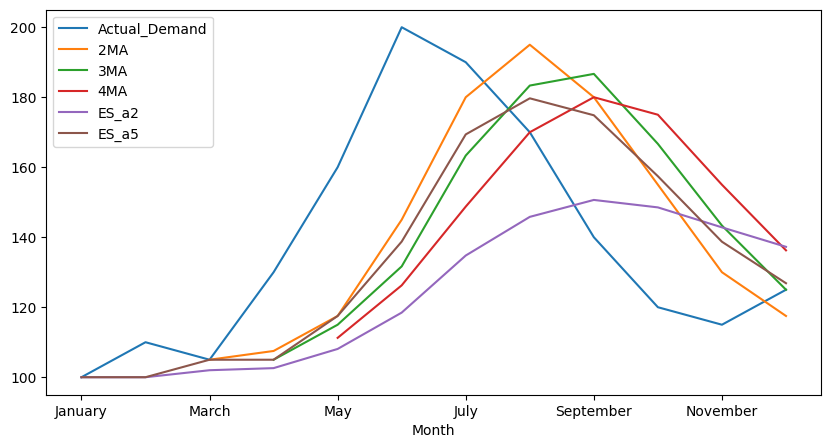

In [14]:
import matplotlib.pyplot as plt
df.plot(x='Month', figsize=(10,5))
plt.show()